# 05 — Parse and Verify Results

This notebook parses the CalculiX result files, computes the verification status,
and plots the measured outputs against the allowed thresholds.

## What this notebook does

- Rebuilds the same deterministic geometry and mesh.
- Runs CalculiX if it is available.
- Parses the `.dat` file for displacement and best-effort stress values.
- Computes pass/fail status and draws a simple summary plot.
- Marks stress parsing as TODO if the required output block is not present.

In [3]:
import json
import logging
import sys
from dataclasses import asdict, is_dataclass
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

def find_module_root(start: Path | None = None) -> Path:
    current = start or Path.cwd()
    for candidate in [current, *current.parents]:
        if (candidate / 'src').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise RuntimeError('Could not locate the fea_cad_one_sample module root.')

def json_safe(value: Any) -> Any:
    if is_dataclass(value):
        return json_safe(asdict(value))
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, dict):
        return {str(key): json_safe(item) for key, item in value.items()}
    if isinstance(value, (list, tuple, set)):
        return [json_safe(item) for item in value]
    return value

def write_json(path: Path, payload: Any) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(json_safe(payload), indent=2, sort_keys=True) + '\n', encoding='utf-8')
    return path

def load_json(path: Path) -> dict[str, Any]:
    return json.loads(Path(path).read_text(encoding='utf-8'))

MODULE_ROOT = find_module_root()
if str(MODULE_ROOT) not in sys.path:
    sys.path.insert(0, str(MODULE_ROOT))

import src.interfaces as iface

plt.style.use('seaborn-v0_8-whitegrid')
print(f'[SETUP] MODULE_ROOT={MODULE_ROOT}')

[SETUP] MODULE_ROOT=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample


In [6]:
import shutil

RUN_DIR = MODULE_ROOT / 'outputs' / 'sample_00689964' / '01_dataset_original'
SOURCE_STEP_PATH = RUN_DIR / "original.step" 
MESH_SIZE_MM = 8.0
LOAD_MAGNITUDE_N = 100.0

print('[STAGE] results: parse and verify')
ccx_path = shutil.which('ccx')
print('  ccx =', ccx_path)
if not ccx_path:
    message = "CalculiX executable 'ccx' was not found on PATH. Install ccx before parsing results."
    print(f'ERROR: FileNotFoundError: {message}')
    raise FileNotFoundError(message)

config = iface.build_baseline_config(
    run_dir=RUN_DIR,
    source_step_path=SOURCE_STEP_PATH,
    mesh_size_mm=MESH_SIZE_MM,
    load_magnitude_n=LOAD_MAGNITUDE_N,
)

INFO src.fea_replication.pipeline: build_baseline_config | start | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original | source_step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step | mesh_size_mm=8.0 | load_magnitude_n=100.0
INFO src.fea_replication.pipeline: build_baseline_config | done | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original


[STAGE] results: parse and verify
  ccx = /opt/homebrew/Caskroom/miniconda/base/envs/cad_physics/bin/ccx


In [7]:

geometry = iface.prepare_geometry_artifacts(config, force=True)
mesh = iface.generate_calculix_mesh(config, geometry, force=True)
solver = iface.run_calculix_solver(config, mesh)
results = iface.parse_calculix_results(config, solver)

print('  parsed_results.json =', results.summary_path)
print(json.dumps(json_safe(results), indent=2))


INFO src.fea_replication.geometry: prepare_geometry_artifacts | start | run_dir=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original | source_step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/original.step | force=True
INFO src.fea_replication.geometry: render_geometry_preview | start | step_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/cantilever_beam.step | output_path=/Users/vedaangchopra/all_data/complete_technical_work/all_projects_implemented/CAD-Physics/code_base/fea_cad_one_sample/outputs/sample_00689964/01_dataset_original/geometry_preview.png | force=True
INFO src.fea_replication.geometry: render_geometry_preview | done | ou

Info    :  - Label 'Shapes/Open CASCADE STEP translator 7.8 1' (3D)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 10%] Meshing curve 2 (Line)
Info    : [ 10%] Meshing curve 3 (Line)
Info    : [ 20%] Meshing curve 4 (Line)
Info    : [ 20%] Meshing curve 5 (Line)
Info    : [ 30%] Meshing curve 6 (Line)
Info    : [ 30%] Meshing curve 7 (Line)
Info    : [ 40%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 50%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 60%] Meshing curve 13 (Line)
Info    : [ 70%] Meshing curve 14 (Circle)
Info    : [ 70%] Meshing curve 15 (Line)
Info    : [ 80%] Meshing curve 16 (Line)
Info    : [ 80%] Meshing curve 17 (Line)
Info    : [ 90%] Meshing curve 18 (Line)
Info    : [ 90%] Meshing curve 19 (Line)
Info    : [100%] Meshing curve 20 (Line)
Info    : [100%] Meshing curve 21 (Circle)
Info    : Done meshing 1D (Wall 0.000463791s, CPU 0.

,metric,value,limit,status
0,max_displacement_mm,None,2.0,False
1,max_von_mises_mpa,None,NaN,None
2,estimated_safety_factor,None,2.0,None


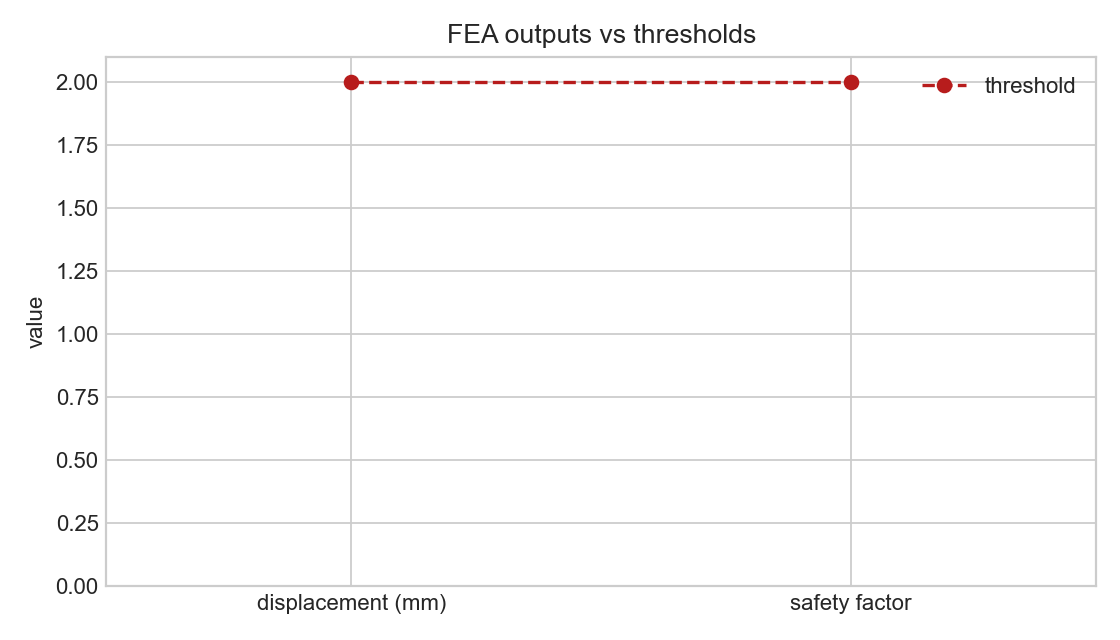

  cgx viewer hint: cgx -v analysis.frd
  notes:
   - Stress parsing TODO: no usable *EL PRINT stress block was detected in the .dat file. The pipeline still records displacement results.
✓ results parsed and verified


In [8]:

rows = [
    {'metric': 'max_displacement_mm', 'value': results.max_displacement_mm, 'limit': config.verification_criteria.max_displacement_mm, 'status': results.passes_displacement},
    {'metric': 'max_von_mises_mpa', 'value': results.max_von_mises_mpa, 'limit': None, 'status': results.passes_safety_factor},
    {'metric': 'estimated_safety_factor', 'value': results.estimated_safety_factor, 'limit': config.verification_criteria.required_safety_factor, 'status': results.overall_pass},
]
df = pd.DataFrame(rows)
display(df)

fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['displacement (mm)', 'safety factor']
values = [results.max_displacement_mm or 0.0, results.estimated_safety_factor or 0.0]
thresholds = [config.verification_criteria.max_displacement_mm, config.verification_criteria.required_safety_factor]
ax.bar(metrics, values, color=['#1565c0', '#2e7d32'])
ax.plot(metrics, thresholds, color='#b71c1c', marker='o', linestyle='--', label='threshold')
ax.set_title('FEA outputs vs thresholds')
ax.set_ylabel('value')
ax.legend()
plot_path = RUN_DIR / 'results_plot.png'
fig.tight_layout()
fig.savefig(plot_path, dpi=160)
display(Image(filename=str(plot_path)))
plt.close(fig)

print('  cgx viewer hint: cgx -v', solver.frd_path.name)
if results.notes:
    print('  notes:')
    for note in results.notes:
        print('   -', note)
print('✓ results parsed and verified')